# Visualization of Raw PD Data

This notebook will visualize the raw Parkinsons' disease data in `data` directory. The data used here will be from the **FIRST DATA SOURCE**.

The goal of the notebook is to analyze the data in a more scientific way than just following the mathematical and algorithmic approach in the reference research paper. This way, we can communicate the findings better with experts and researchers in the field to validate our methodology and results.

With that in mind, we will reduce reliance on the existing `preprocessors` utilities and instead produce another perspective using raw functions, and compare the results and expert judgements in order to "debug" our current approach.

In [1]:
import mne, pickle
from scipy.signal import firwin, lfilter
import matplotlib.pyplot as plt

First do some basic preprocessing and visualization of the accelerometer data. A fun obversation, these samples differ **A LOT** between different trials / patients.

**Note that interactive plots won't work in Jupyter as well for anything plt based, so make sure you copy and paste to run this block as a script**

In [ ]:
# load the data
ACC_DATA_PATH = "../data/accelerometer_data/802_1_accelerometer.pkl"

with open(ACC_DATA_PATH, "rb") as f:
    acc_data = pickle.load(f)

print(f"Loaded accelerometer data with shape: {acc_data.shape}")

# bandpass filter the data
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b = firwin(order + 1, [low, high], pass_zero=False)
    return lfilter(b, 1.0, data)

# Apply the bandpass filter to the accelerometer data
# fs here is the sampling frequency of the accelerometer data
filtered = bandpass_filter(acc_data, lowcut=1, highcut=30.0, fs=100, order=5)
print(f"Filtered data with shape: {filtered.shape}")

# plot this data interactively so they can zoom
def plot_acc_data(data, title="Accelerometer Data", fs=100):
    time_axis = [i / fs for i in range(data.shape[1])]  # Convert samples to time
    plt.figure(figsize=(10, 6))
    for i, axis in enumerate(['X', 'Y', 'Z']):
        plt.plot(time_axis, data[i], label=f'{axis}-axis')
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

plot_acc_data(filtered, title="Filtered Accelerometer Data")

Loaded accelerometer data with shape: (3, 93501)


Now let's line them up with the EEG data (from O1 and O2 channels) so that they know if these are really tremor times or not and we can use that to debug....

**Note that I will rewrite this entire from scratch without using EEG preprocessor class**

Also, it seems like interactive graphs won't work in Notebook in general, so plesase copy this block and run it as a script...

In [ ]:
EEG_DATA_PATH = "../data/eeg_data/802_1_PD_REST-epo.fif"
eeg_data = mne.io.read_raw_fif(EEG_DATA_PATH, preload=True)

# eeg_data.plot()
print(eeg_data.info)
print(eeg_data.get_data()[:5])

# not sure why needed
eeg_data._data *= 1e-6

# apply the bandpass filter
eeg_data.filter(l_freq=0.5, h_freq=50.0)

# select a list of specific channels
print(f"Original channel names: {eeg_data.ch_names}")
channels = ["O1", "O2"]
eeg_data.pick_channels(channels)

eeg_data.plot() # plot the raw time domain data
eeg_data.compute_psd().plot() # power time frequency ploto

# plt.show()


Lastly we compare the results against our predictions (the timestamps from accelerometer algorithm)

In [18]:
import sys
sys.path.append("../")
from preprocessors.acc_preprocessor import AccelerometerPreprocessor

Drift removal
Bandpass filter
Segment data
Shape after window segmenting: (3, 3214, 300)
Detect peak frequency
Map dominant frequencies to time
Shape after mapping: (3, 93501)
Smooth data
Multiply
Thresholding
Feature extraction


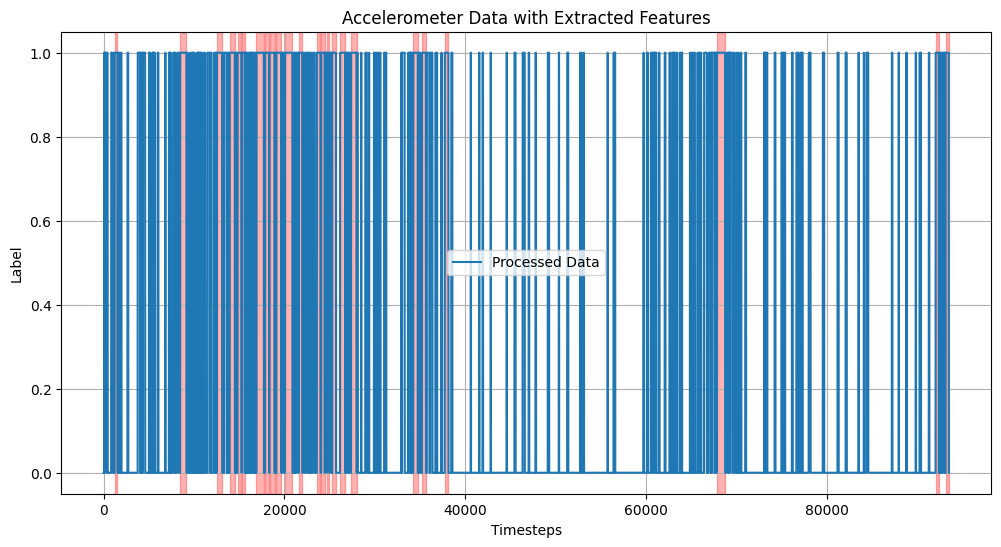

In [19]:
acc_loader = AccelerometerPreprocessor(ACC_DATA_PATH, 100)
timestamps = acc_loader.preprocess_data()
# acc_loader.plot_data()
acc_loader.visualize_features()

I also think it would be helpful if they can check over the logic of our algorithm even though not the code